# Bioinformatics Mid Term Exam (Wijesh Kumar)

## Importing  Required Libries

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Read CSV Format Dataset using Pandas 

In [2]:
diseases = pd.read_csv("dataset/diseases_pakistan.csv")
drugs = pd.read_csv("dataset/drugs.csv")
genes = pd.read_csv("dataset/genes.csv")

## Rename columns for consistency in Creating Knowledge Graph 

In [3]:
diseases.columns = ['node_id', 'node_name']
drugs.columns = ['node_id', 'node_name']
genes.columns = ['node_id', 'node_name']

# Add node types
diseases['node_type'] = 'Disease'
drugs['node_type'] = 'Drug'
genes['node_type'] = 'Gene'

## Combine all nodes and Save in Nodes.csv file 

In [4]:
nodes = pd.concat([diseases, drugs, genes], ignore_index=True)
nodes = nodes.drop_duplicates(subset="node_id")

nodes.to_csv("dataset/nodes.csv", index=False)

nodes.head()

,node_id,node_name,node_type
0,DS1,Tuberculosis,Disease
1,DS2,Hepatitis B,Disease
2,DS3,Hepatitis C,Disease
3,DS4,Dengue Fever,Disease
4,DS5,Malaria,Disease


## Create Edges for Knowlege Graph 

In [5]:
edges = []

# Drug treats Disease edge 
for i in range(min(len(drugs), len(diseases))):
    edges.append({
        "source": drugs.iloc[i]['node_id'],
        "target": diseases.iloc[i]['node_id'],
        "relation": "treats"
    })

# Gene associated_with Disease edge 
for i in range(min(len(genes), len(diseases))):
    edges.append({
        "source": genes.iloc[i]['node_id'],
        "target": diseases.iloc[i]['node_id'],
        "relation": "associated_with"
    })

# Drug targets Gene edge
for i in range(min(len(drugs), len(genes))):
    edges.append({
        "source": drugs.iloc[i]['node_id'],
        "target": genes.iloc[i]['node_id'],
        "relation": "targets"
    })

# Convert all edges into DataFrame
edges_df = pd.DataFrame(edges)

## Creating Edges Csv file Save in edges.csv file

In [6]:
edges_df = edges_df.drop_duplicates()

edges_df.to_csv("dataset/edges.csv", index=False)

edges_df.head()


,source,target,relation
0,D1,DS1,treats
1,D2,DS2,treats
2,D3,DS3,treats
3,D4,DS4,treats
4,D5,DS5,treats


## Creating Knowledge GRAPH Using networkx Library

In [7]:

G = nx.Graph()

# Add nodes in Graph
for _, row in nodes.iterrows():
    G.add_node(row['node_id'],
               label=row['node_name'],
               type=row['node_type'])

# Add edges in Graph
for _, row in edges_df.iterrows():
    G.add_edge(row['source'],
               row['target'],
               relation=row['relation'])



## VISUALIZATION of Knowledge Graph Using matplotlib Library

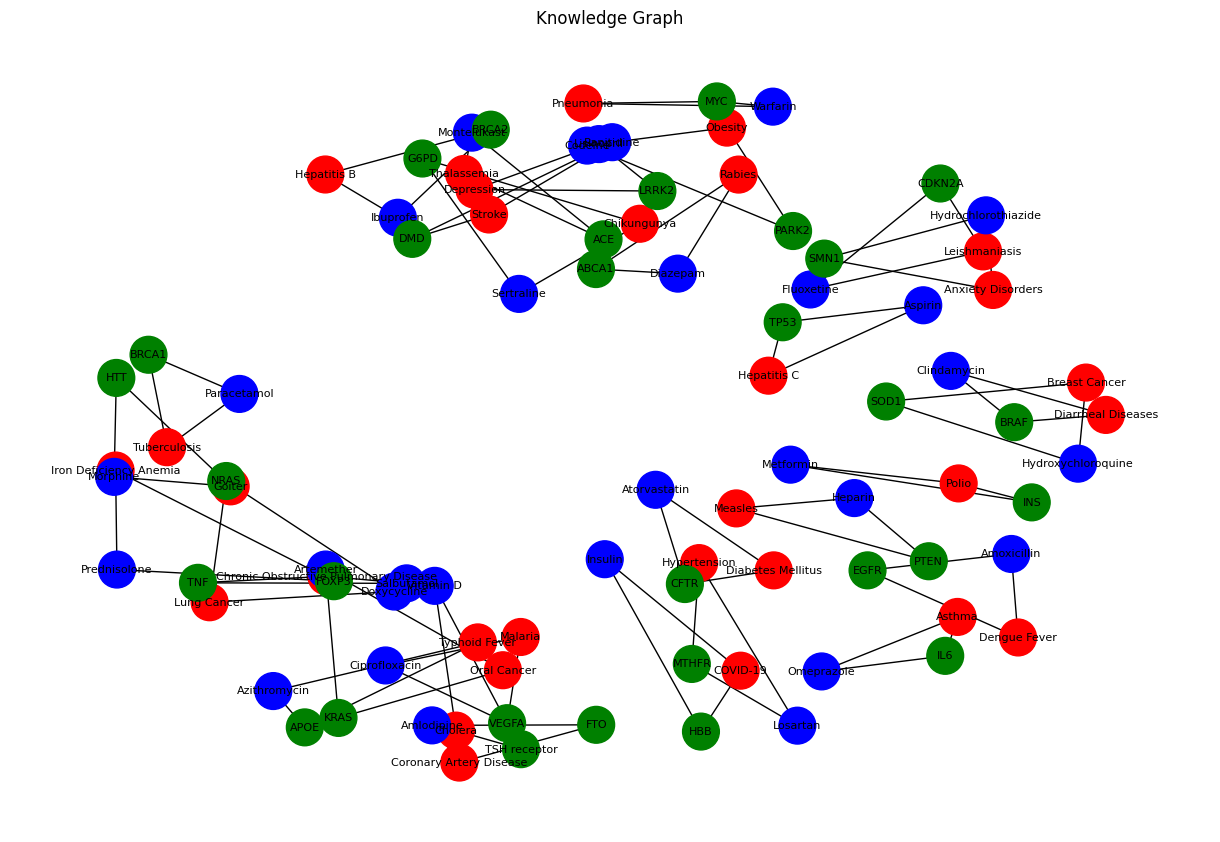

In [8]:

plt.figure(figsize=(12, 8))

# Layout of Graph
pos = nx.spring_layout(G, k=0.5)

# Labels 
labels = {node: data['label'] for node, data in G.nodes(data=True)}

# Color of nodes by thier type
color_map = []
for node in G.nodes(data=True):
    if node[1]['type'] == "Disease":
        color_map.append('red')
    elif node[1]['type'] == "Drug":
        color_map.append('blue')
    else:
        color_map.append('green')

nx.draw(G, pos,
        labels=labels,
        node_color=color_map,
        node_size=700,
        font_size=8)

plt.title("Knowledge Graph")
plt.show()


## BUILD GRAPH FOR EACH NODE (10 node for this demo) 

Showing graph for: Tuberculosis


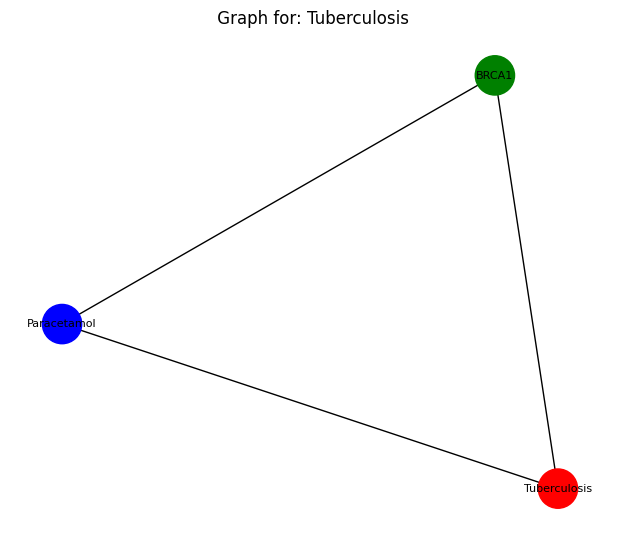

Showing graph for: Hepatitis B


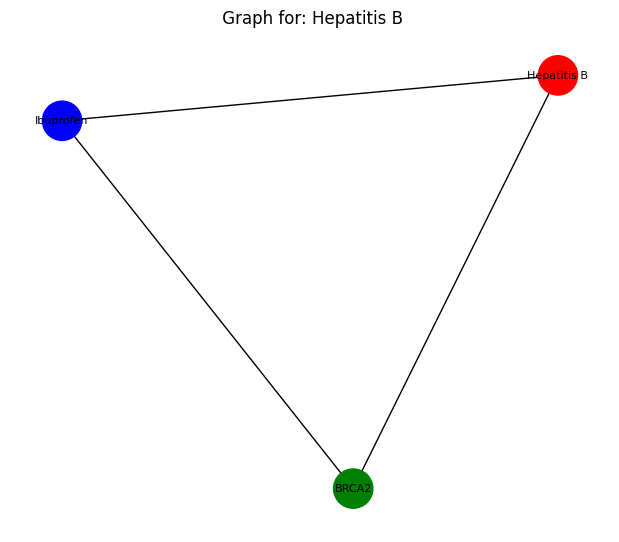

Showing graph for: Hepatitis C


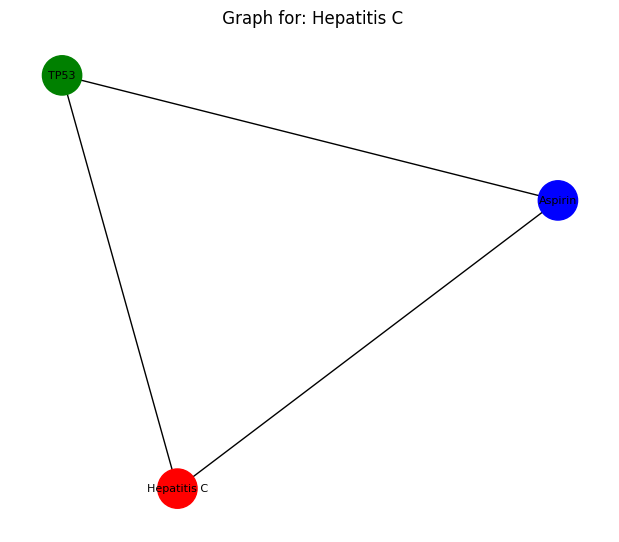

Showing graph for: Dengue Fever


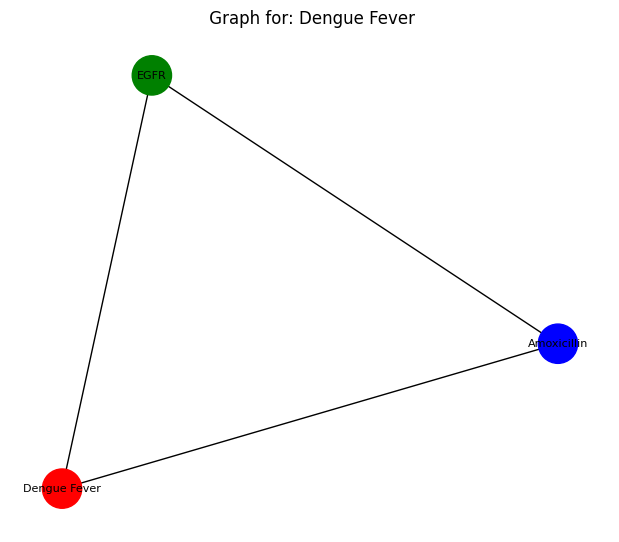

Showing graph for: Malaria


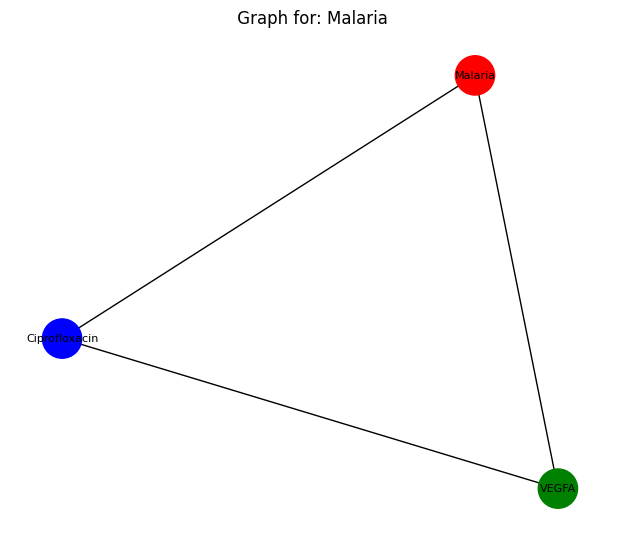

Showing graph for: Typhoid Fever


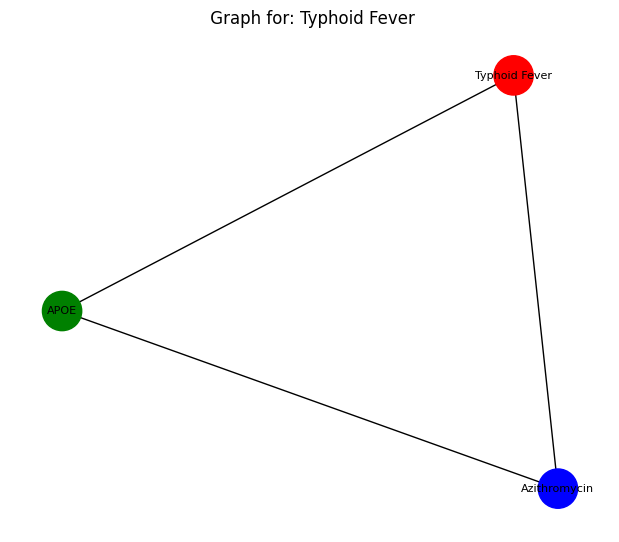

Showing graph for: Polio


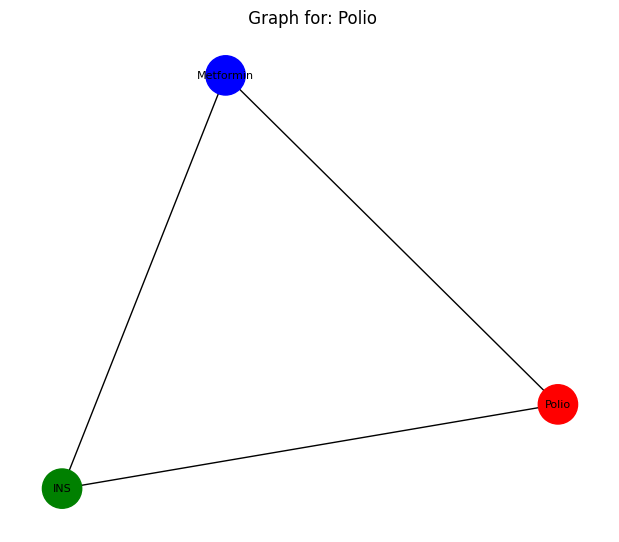

Showing graph for: COVID-19


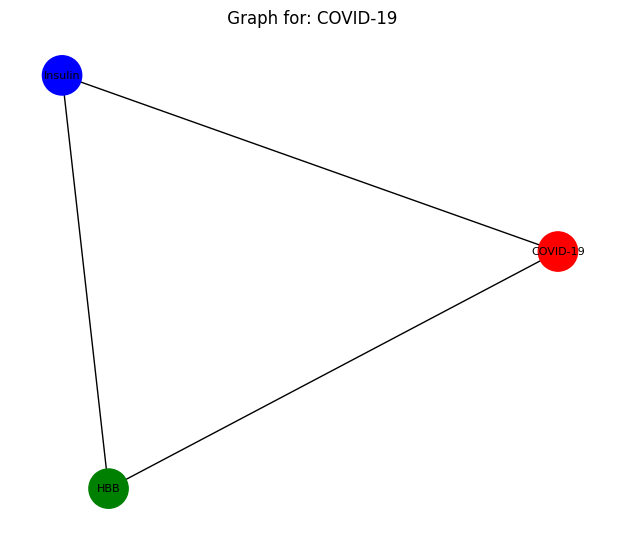

Showing graph for: Diabetes Mellitus


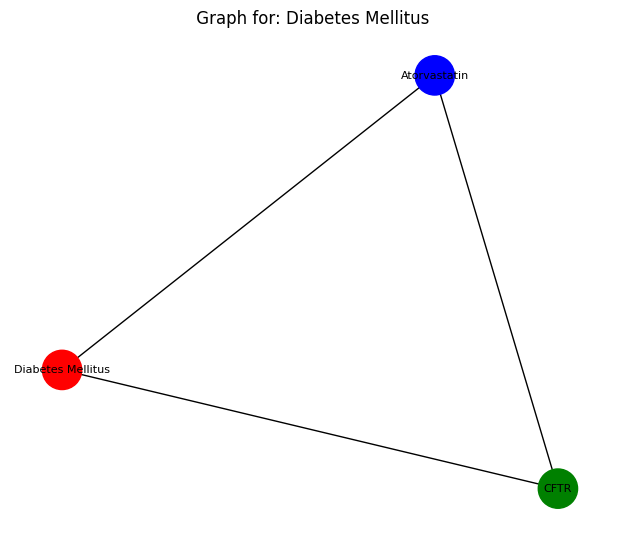

Showing graph for: Hypertension


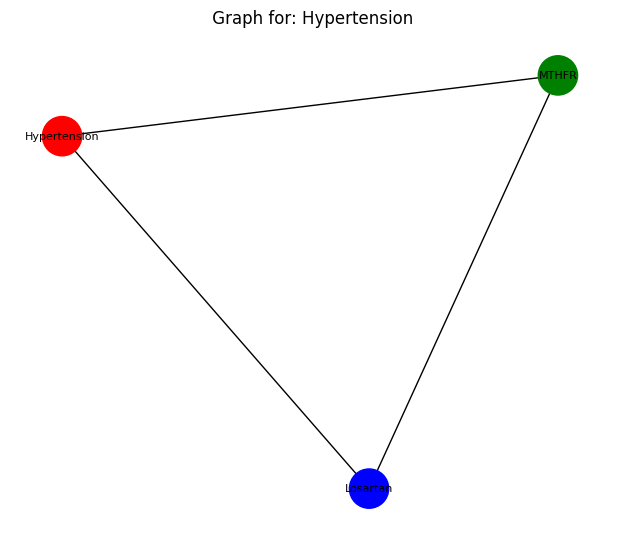

In [9]:
def plot_ego_graph(G, center_node):
    # Extract  graph (1-hop neighbors)
    ego = nx.ego_graph(G, center_node, radius=1)

    plt.figure(figsize=(6,5))
    pos = nx.spring_layout(ego)

    # Labels 
    labels = {node: G.nodes[node]['label'] for node in ego.nodes()}

    # Color mapping
    color_map = []
    for node in ego.nodes(data=True):
        if node[1]['type'] == "Disease":
            color_map.append('red')
        elif node[1]['type'] == "Drug":
            color_map.append('blue')
        else:
            color_map.append('green')

    nx.draw(ego, pos,
            labels=labels,
            node_color=color_map,
            node_size=800,
            font_size=8)

    plt.title(f" Graph for: {G.nodes[center_node]['label']}")
    plt.show()

#  LOOP THROUGH ALL NODES
for node in list(G.nodes())[:10]:   # first 10 for this demo
    print(f"Showing graph for: {G.nodes[node]['label']}")
    plot_ego_graph(G, node)

## VALIDATION of Nodes and Edges and Relationship 

In [10]:
# Prints Nodes and Edges 

print("Total Nodes:", G.number_of_nodes())
print("Total Edges:", G.number_of_edges())


# Unique relation types
print("Relation Types:", edges_df['relation'].unique())


Total Nodes: 90
Total Edges: 90
Relation Types: ['treats' 'associated_with' 'targets']


# 2nd Knowledge Graph: Clinical Context

## Adding symptoms and Risk Factors Data to Extend the Knowlege Graph

In [11]:
symptoms = pd.read_csv("dataset/symptoms.csv")
risks = pd.read_csv("dataset/risk_factors.csv")

# Standardize the data of symptoms and Risk Factor in nodes 
symptoms.columns = ['node_id', 'node_name']
risks.columns = ['node_id', 'node_name']

symptoms['node_type'] = 'Symptom'
risks['node_type'] = 'RiskFactor'


# EXTEND NODE TABLE with symptoms and Risk Factor dataset

nodes_extended = pd.concat([nodes, symptoms, risks], ignore_index=True)

# =====================================================
# Adding NEW RELATIONSHIPS

edges_ext = []

# Disease and Symptom
for i in range(min(len(diseases), len(symptoms))):
    edges_ext.append({
        "source": diseases.iloc[i]['node_id'],
        "target": symptoms.iloc[i]['node_id'],
        "relation": "has_symptom"
    })

# Disease and Risk Factor
for i in range(min(len(diseases), len(risks))):
    edges_ext.append({
        "source": diseases.iloc[i]['node_id'],
        "target": risks.iloc[i]['node_id'],
        "relation": "caused_by"
    })

# Risk and Disease
for i in range(min(len(risks), len(diseases))):
    edges_ext.append({
        "source": risks.iloc[i]['node_id'],
        "target": diseases.iloc[i]['node_id'],
        "relation": "increases_risk"
    })

# Combine the edges with previous edges
edges_extended = pd.concat([edges_df, pd.DataFrame(edges_ext)], ignore_index=True)


## Creating Extended Knowledge Graph with new Edges and Nodes

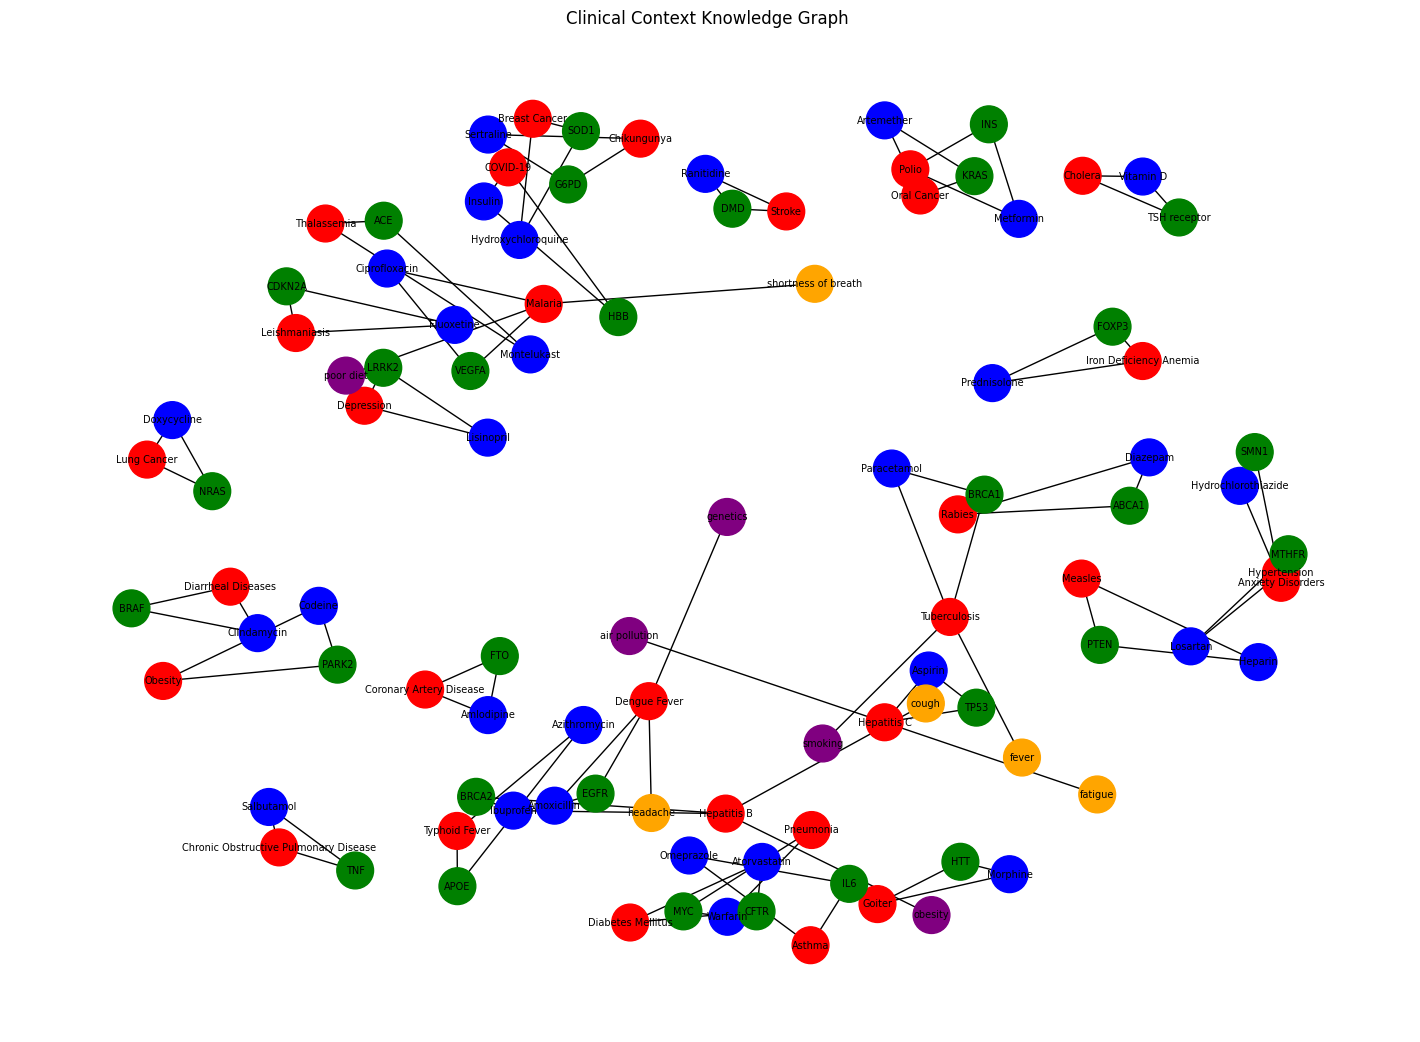

In [12]:
G2 = nx.Graph()

# Add nodes
for _, row in nodes_extended.iterrows():
    G2.add_node(row['node_id'],
                label=row['node_name'],
                type=row['node_type'])

# Add edges
for _, row in edges_extended.iterrows():
    G2.add_edge(row['source'],
                row['target'],
                relation=row['relation'])


# VISUALIZATION of Extended Knowledge Graph
plt.figure(figsize=(14,10))
pos = nx.spring_layout(G2, k=0.4)

labels = {n: G2.nodes[n]['label'] for n in G2.nodes()}

# Color mapping of Nodes
color_map = []
for node in G2.nodes(data=True):
    t = node[1]['type']
    if t == "Disease":
        color_map.append('red')
    elif t == "Drug":
        color_map.append('blue')
    elif t == "Gene":
        color_map.append('green')
    elif t == "Symptom":
        color_map.append('orange')
    else:
        color_map.append('purple')

nx.draw(G2, pos,
        labels=labels,
        node_color=color_map,
        node_size=700,
        font_size=7)

plt.title("Clinical Context Knowledge Graph ")
plt.show()



## VALIDATION of Extended Knowledge Graph (Nodes and Edges and Relationship) 

In [13]:

print("Nodes:", G2.number_of_nodes())
print("Edges:", G2.number_of_edges())

print("Node Types:", set(nx.get_node_attributes(G2, 'type').values()))

relations = [d['relation'] for _,_,d in G2.edges(data=True)]
print("Relations:", set(relations))

Nodes: 100
Edges: 100
Node Types: {'Gene', 'Symptom', 'Drug', 'Disease', 'RiskFactor'}
Relations: {'increases_risk', 'has_symptom', 'targets', 'associated_with', 'treats'}
